In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import json
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
import scienceplots

from collections import defaultdict

In [2]:
DARK_BLUE  = (0.0, 0.4667, 0.7333)
LIGHT_BLUE = (0.2, 0.7333, 0.9333)
GREEN      = (0.0, 0.6, 0.5333)
ORANGE     = (0.9333, 0.4667, 0.2)
RED        = (0.8, 0.2, 0.0667)
PINK       = (0.9333, 0.2, 0.4667)
GRAY       = (0.7333, 0.7333, 0.7333)

SAVE = False

In [3]:
FOLDER = '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/02_25_17_16_LR_1_PW_04__HigherDeltaBCM_Record_Fig1'
TRIAL = 8
T_INIT = 300
DT_SIM = 0.1
DT_RECORD = 0.01

In [4]:
data = {}

for file in os.listdir(FOLDER):
    file_name = os.path.join(FOLDER, file)
        
    if f"_{TRIAL}_weights.csv" in file_name:
        loaded_data = np.genfromtxt(file_name, delimiter=',', names=True, dtype=None, encoding='utf-8')
        data['pre'] = loaded_data['pre']
        data['post'] = loaded_data['post']
    
    if f"_{TRIAL}_weights_time.npy" in file_name:
        data['ws'] = np.load(file_name)
        
    if f"_{TRIAL}_neuron_ids" in file_name:
        with open(file_name, "r") as f:
            neuron_ids = json.load(f)
            data['ids'] = neuron_ids
            
    if f"_{TRIAL}_simulation_states" in file_name:
        sim_states = np.genfromtxt(file_name, delimiter=',', names=True, dtype=None, encoding='utf-8')
        data['sim states'] = sim_states
        
    if f"_{TRIAL}_rates_time.npy" in file_name:
        data['rs'] = np.load(file_name)

/var/folders/5j/y5kkrfqd203frqztz88nnmqr0000gn/T/ipykernel_63972/2903376532.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(
/var/folders/5j/y5kkrfqd203frqztz88nnmqr0000gn/T/ipykernel_63972/2903376532.py:30: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(


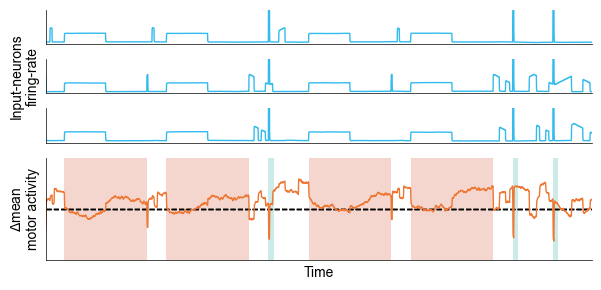

In [ ]:
plt.style.use(['nature_d'])

fig, axs = plt.subplot_mosaic([["Rates_Input_1"],
                               ["Rates_Input_2"],
                               ["Rates_Input_3"],
                               ["Rates_Motor"],
                            #    ["Weights"]],
],
                              sharex=True,
                              height_ratios=[1,1,1,3])

rate_axs = [axs[f"Rates_Input_{i+1}"] for i in range(3)]


# for ax in axs.values():
for ax in [axs["Rates_Motor"]]:
    for i, sim_state in enumerate(data['sim states']):
            if sim_state['pong_state'] == 'miss':
                time = sim_state['network_time']
                ax.axvspan(
                    time,
                    time + 8,
                    alpha=0.2,
                    color=RED,
                    edgecolor='none',
                    linewidth=0
                )
            if sim_state['pong_state'] == 'hit':
                time = sim_state['network_time']
                ax.axvspan(
                time,
                time + 0.5,
                alpha=0.2,
                color=GREEN,
                edgecolor='none',
                linewidth=0
                )


ids_in = np.array([6, 12, 15])
for i, (stim_id, ax) in enumerate(zip(np.array(data['ids']['stimulation_ids'])[ids_in], rate_axs)):
    
    xs = np.arange(0, data['rs'].shape[1]) * DT_RECORD
    ax.plot(xs, data['rs'][stim_id].T, color=LIGHT_BLUE, alpha=1.0)
    
    ax.set_ylim([0, 20])
    
# weights = data['ws'][data['pre'] == data['ids']['stimulation_ids'][9]]
# axs["Weights"].plot(xs, weights.T, color=GRAY)
    axs["Rates_Motor"].axhline(0, color='black', linestyle='--')
motor_mean = []    
for motor_ids in [data['ids']['motor_ids_U'], data['ids']['motor_ids_D']]:
    motor_mean.append(np.mean(data['rs'][motor_ids], axis=0))
axs["Rates_Motor"].plot(xs, (motor_mean[0] - motor_mean[1]), color=ORANGE)
    
axs["Rates_Motor"].set_ylim([-0.2, 0.2])

ax.set_xlim([397, 450])


for ax in axs.values():
    ax.tick_params(
        axis='both',
        which='both',
        bottom=False,
        top=False,
        left=False,
        right=False,
        labelbottom=False,
        labelleft=False
    )
    
axs["Rates_Motor"].set_xlabel("Time")
axs["Rates_Motor"].set_ylabel(r"$\Delta$" + "mean\nmotor activity")
axs["Rates_Input_2"].set_ylabel("Input-neurons\nfiring-rate")

w, h = fig.get_size_inches()
fig.set_size_inches(w, 3.)

fig.tight_layout()

if SAVE:
    fig.savefig("fig_1_traces.pdf", dpi=300)
    
plt.show()

/var/folders/5j/y5kkrfqd203frqztz88nnmqr0000gn/T/ipykernel_63972/2832391702.py:58: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(time, time + 8, alpha=0.2, color=RED, edgecolor='none', linewidth=0)
/var/folders/5j/y5kkrfqd203frqztz88nnmqr0000gn/T/ipykernel_63972/2832391702.py:61: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(time, time + 0.5, alpha=0.2, color=GREEN, edgecolor='none', linewidth=0)


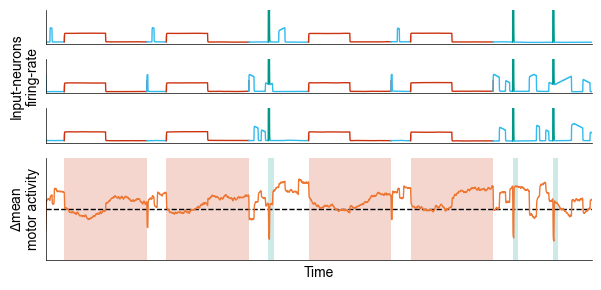

In [14]:
plt.style.use(['nature_d'])
fig, axs = plt.subplot_mosaic([["Rates_Input_1"], ["Rates_Input_2"], ["Rates_Input_3"], ["Rates_Motor"]], 
                               sharex=True, height_ratios=[1,1,1,3])
rate_axs = [axs[f"Rates_Input_{i+1}"] for i in range(3)]

# Build list of (start, end, color) segments from sim_states
segments = []
xs_full = np.arange(0, data['rs'].shape[1]) * DT_RECORD
x_min, x_max = xs_full[0], xs_full[-1]

# Collect event intervals
events = []
for sim_state in data['sim states']:
    if sim_state['pong_state'] == 'miss':
        t = sim_state['network_time']
        events.append((t, t + 8, RED))
    elif sim_state['pong_state'] == 'hit':
        t = sim_state['network_time']
        events.append((t, t + 0.15, GREEN))

# Sort events by start time
events.sort(key=lambda e: e[0])

# Build segments: gaps between events are LIGHT_BLUE
colored_segments = []
cursor = x_min
for (t_start, t_end, color) in events:
    if cursor < t_start:
        colored_segments.append((cursor, t_start, LIGHT_BLUE))
    colored_segments.append((t_start, t_end, color))
    cursor = t_end
if cursor < x_max:
    colored_segments.append((cursor, x_max, LIGHT_BLUE))

def plot_segmented(ax, xs, ys, segments):
    """Plot ys vs xs using color segments defined as (x_start, x_end, color)."""
    for (x_start, x_end, color) in segments:
        mask = (xs >= x_start) & (xs <= x_end)
        if not np.any(mask):
            continue
        # Find indices, extend by 1 on each side to avoid gaps at boundaries
        idx = np.where(mask)[0]
        i0 = max(idx[0] - 1, 0)
        i1 = min(idx[-1] + 1, len(xs) - 1)
        ax.plot(xs[i0:i1+1], ys[i0:i1+1], color=color, alpha=1.0)

ids_in = np.array([6, 12, 15])
for i, (stim_id, ax) in enumerate(zip(np.array(data['ids']['stimulation_ids'])[ids_in], rate_axs)):
    xs = np.arange(0, data['rs'].shape[1]) * DT_RECORD
    plot_segmented(ax, xs, data['rs'][stim_id], colored_segments)
    ax.set_ylim([0, 20])

# Motor panel spans (unchanged)
for ax in [axs["Rates_Motor"]]:
    for sim_state in data['sim states']:
        if sim_state['pong_state'] == 'miss':
            time = sim_state['network_time']
            ax.axvspan(time, time + 8, alpha=0.2, color=RED, edgecolor='none', linewidth=0)
        if sim_state['pong_state'] == 'hit':
            time = sim_state['network_time']
            ax.axvspan(time, time + 0.5, alpha=0.2, color=GREEN, edgecolor='none', linewidth=0)

axs["Rates_Motor"].axhline(0, color='black', linestyle='--')
motor_mean = []
for motor_ids in [data['ids']['motor_ids_U'], data['ids']['motor_ids_D']]:
    motor_mean.append(np.mean(data['rs'][motor_ids], axis=0))
axs["Rates_Motor"].plot(xs, (motor_mean[0] - motor_mean[1]), color=ORANGE)
axs["Rates_Motor"].set_ylim([-0.2, 0.2])

ax.set_xlim([397, 450])

for ax in axs.values():
    ax.tick_params(axis='both', which='both',
                   bottom=False, top=False, left=False, right=False,
                   labelbottom=False, labelleft=False)

axs["Rates_Motor"].set_xlabel("Time")
axs["Rates_Motor"].set_ylabel(r"$\Delta$" + "mean\nmotor activity")
axs["Rates_Input_2"].set_ylabel("Input-neurons\nfiring-rate")

w, h = fig.get_size_inches()
fig.set_size_inches(w, 3.)
fig.tight_layout()
if True:
    fig.savefig("fig_1_traces.pdf", dpi=300)
plt.show()